#### Name: 

# PHYS 230 Lab Assignment 12

### Wednesday, March 4, 2026: Chapter 6.3.1 - 6.3.4
- Nonlinear equations part 1

In [20]:
# put all import statements here
import numpy as np
import matplotlib.pyplot as plt

## Relaxation Method - 2 variable (25  points)

Use the relaxation method to solve for x and y in the following nonlinear equations: 

$$ 3x - \frac{1}{y} = -1 $$
$$2x^2 - y = 0$$

To do this: 
1) First solve the first equation for $x$ and the second equation for $y$. Put this in a markdown cell. 

2) Make an initial guess for $x$ and $y$ by thinking about one of the equations and determine number of iterations. Explain reasoning in markdown or commenting 

3) Apply the relaxation method (check class notebook) via a user-defined function `relax_method(N,x,y)`. Call on your function and see if it works! 

4) If it doesn't converge, try solving the inverse equations for $x$ and $y$ and try calling your relaxation method function again. 

*You must clearly comment your code and include a markdown cell explaining your process*

$$y=2x^2$$
$$x=\frac{1}{3y}-\frac{1}{3}$$
Note that we should expect:
$$x=\frac{1}{6x^2}-\frac{1}{3}$$

##### Part 1 (double click cell to add your equation)

In [ ]:
# part 2
x = 1/2 #starting equations
y = 1/2
N = 50
def X(x,y): #X function
    return 1/(3*y) - 1/3
def Y(x,y): #Y function
    return 2*x**2
def relax_method(N,x,y): #Our relaxation method
    for i in range(N):
        x,y = X(x,y),Y(x,y)
    return x,y

x_result, y_result = relax_method(N,x,y)
print(x_result, y_result)
print(X(x_result, y_result),Y(x_result, y_result)) #notice that x,y dne X,Y!

-0.2920847415188823 0.17062699245630458
1.620245807544367 0.17062699245630458


The method above didn't work so we find new functions:
$$x = \sqrt{y/2}$$
$$y = \frac{1}{3x+1}$$

In [ ]:
# part 2
x = 1/2 #starting equations
y = 1/2
N = 50
def X(x,y): #X function
    return np.sqrt(y/2)
def Y(x,y): #Y function
    return 1/(3*x + 1)
def relax_method(N,x,y): #Our relaxation method
    for i in range(N):
        x,y = X(x,y),Y(x,y)
    return x,y

x_result, y_result = relax_method(N,x,y)
print(x_result, y_result)
print(X(x_result, y_result),Y(x_result, y_result)) #notice that x,y equals X,Y!

0.4587195791613034 0.4208473046118466
0.4587195791613034 0.42084730461185


## Binary Search (25 pts)

Use the binary search method to find the roots of $f(x) = 5e^{-x} +x -5$. 

To do this: 
1) Start by defining two functions: `f(x)` which returns the given function in the problem and `binary_solve(f,x1,x2,accuracy)` which applies the binary search method for a given function $f(x)$ based on two initial values $x_1, x_2$, and continues to iterate until a given accuracy is achieved. 

2) Call the function and analyze the results. [Use a graph to estimate the interval that returns a non-zero $x$.] 

3) Plot this point as a magenta star on the graph from step 2 to see if it agrees. 


*You must clearly comment your code and include a markdown cell explaining your process*

In [44]:
# part 1
def binary_solver(x1,x2,f,acc):
    f1,f2 = f(x1),f(x2)
    print(f1,f2)
    if abs(f1+f2)<abs(f1-f2):
        while abs(x2-x1)>acc:
            x_prime = (x2+x1)/2
            f_prime = f(x_prime)
            if f1*f_prime>0:
                x1,f1 = x_prime,f_prime
            else:
                x2,f2 = x_prime,f_prime
        result = (x1+x2)/2
    else:
        exit
    return result
def f(x):
    return 5*np.exp(-x)+x-5
x1,x2 = -1,1
acc = 1e-8

result1 = binary_solver(x1,x2,f,acc)
print(result1)
x1_,x2_ = 4,6
acc = 1e-8

result2 = binary_solver(x1_,x2_,f,acc)
print(result2)

7.591409142295225 -2.1606027941427883
-3.725290298461914e-09
-0.9084218055563289 1.0123937608833318
4.9651142321527


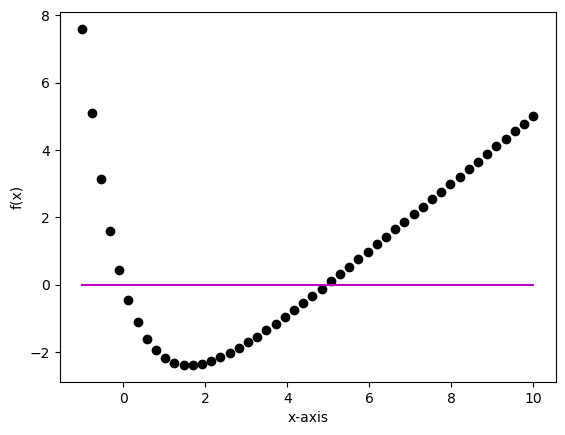

In [40]:
# part 2
N = 50
X = np.linspace(-1,10,N)
Zero = np.zeros(N)
plt.plot(X,f(X), "ko")
plt.plot(X,Zero, "m")
plt.xlabel("x-axis")
plt.ylabel("f(x)")
plt.show()

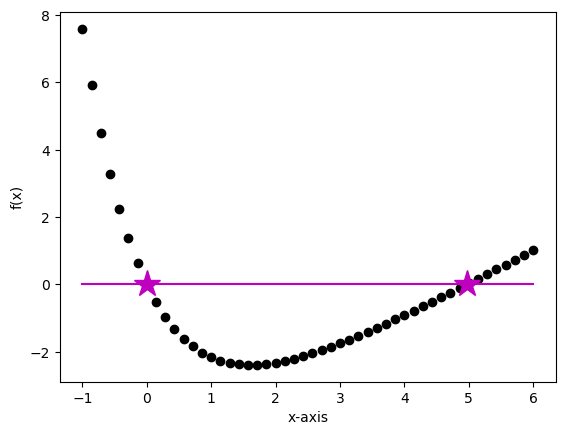

In [46]:
# part 3
N = 50
X = np.linspace(-1,6,N)
Zero = np.zeros(N)
plt.plot(X,f(X), "ko")
plt.plot(result1,f(result1), "m*", ms = 20)
plt.plot(result2,f(result2), "m*", ms = 20)
plt.plot(X,Zero, "m")
plt.xlabel("x-axis")
plt.ylabel("f(x)")
plt.show()

## Energy of an electron in a square potential well

Consider a square potential well of width $w$, with walls of height $V$: 

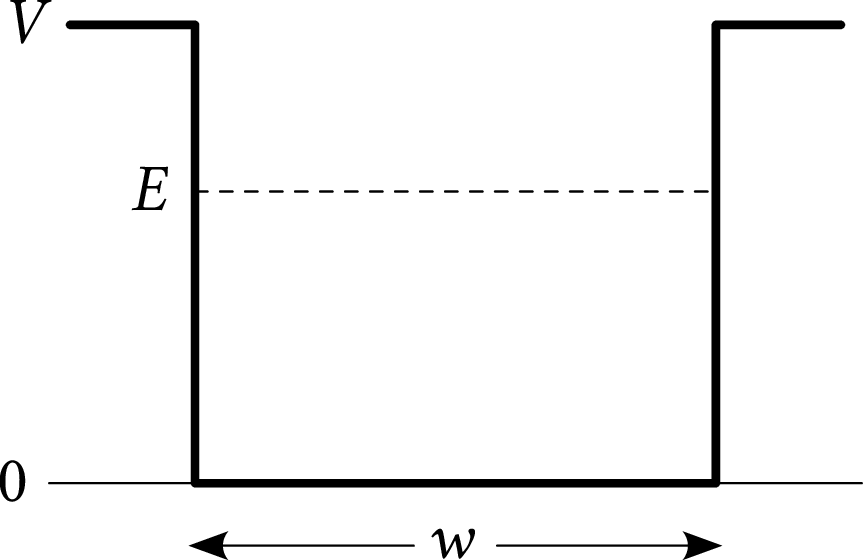

Using Schrödinger's equation, it can be shown that the allowed energies $E$ of a single quantum particle of mass $m$ trapped in the well are solutions of 
$$ \tan{\sqrt{w^2mE/2\hbar^2}} = \begin{cases} 
\sqrt{(V-E)/E} & \text{ for the even numbered states} \\
-\sqrt{E/(V-E)} & \text{ for the odd numbered states} 
\end{cases}
$$

where the states are labeled with integers starting from 0 and working upward, the ground state being state 0, the first excited state being state 1, and so forth. 

a) For an electron of (mass $9.1094 \times 10^{-31}$ kg) in a well with $V = 20 \text{ eV}$ and $w = 1 \text{ nm}$, write a Python program to plot the three quantities 
$$y_1 = \tan{\sqrt{w^2mE/2\hbar^2}} \hspace{0.2in} y_2 = \sqrt{\frac{V-E}{E}} \hspace{0.2in} y_2 = -\sqrt{\frac{E}{V-E}}, $$

on the same graph, as a function of $E$ from $E = 0$ to $E = 20 \text{ eV}$. **Hint** You may find it useful to define functions to calculate $y_1$, $y_2$, and $y_3$. 

b) From your plot make approximate estimates of the energies of the first six energy levels of the particle. 

c) Write a program to calculate the values of the first six energy levels in electron volts to an accuracy of $0.001 \text{ eV}$ using binary search. 

*hint, remember that energies need to be converted to joules in the $y_1$ equation above*

*You must clearly comment your code and include a markdown cell explaining your process*

C:\Users\cbake\AppData\Local\Temp\ipykernel_5556\1499659881.py:18: RuntimeWarning: divide by zero encountered in divide
  return -np.sqrt(E/(potential-E))


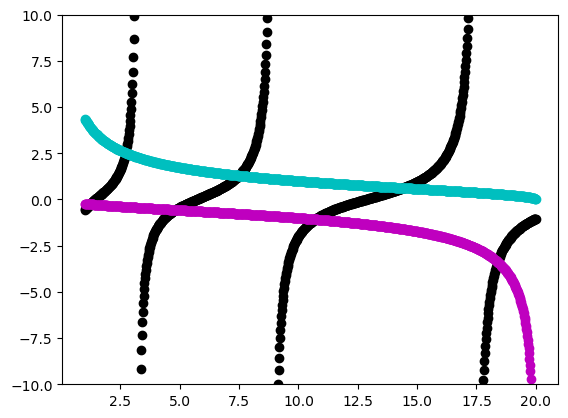

In [ ]:
#a) 
#Constants
mass = 9.1094e-31               #kg
potential = 20                  #eV
w = 1e-9                        #m
h_bar = 1.0546e-34              #eV.s/rad
charge = 1.69e-19               #C
E = np.linspace(1,20,1000)      #eV
Zero = np.linspace(0,0,1000)    #Zero


#User Defined Functions
def Y_1(E):
    return np.tan(np.sqrt((w**2 * mass * E * charge)/ (2 * h_bar**2)))
def Y_2(E):
    return np.sqrt((potential-E)/E)
def Y_3(E):
    return -np.sqrt(E/(potential-E))
def f_even(E):
    return Y_1(E)-Y_2(E)
def f_odd(E):
    return Y_1(E)-Y_3(E)

plt.scatter(E,Y_1(E),c="k")
plt.scatter(E,Y_2(E),c="c")
plt.scatter(E,Y_3(E),c="m")
plt.ylim(-10,10)
plt.show()

C:\Users\cbake\AppData\Local\Temp\ipykernel_5556\1499659881.py:18: RuntimeWarning: divide by zero encountered in divide
  return -np.sqrt(E/(potential-E))


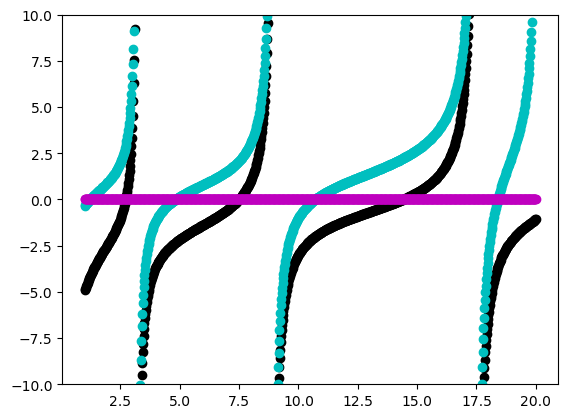

In [82]:
#b) 
plt.scatter(E,f_even(E),c="k")
plt.scatter(E,f_odd(E),c="c")
plt.scatter(E,Zero,c="m")
plt.ylim(-10,10)
plt.show()

Notice that we have zeros at approximately:

Even: 2<3, 5<7.5, 12.5<15

Odd: 1<2.5, 2.5<5, 8<11, 17<20

In [152]:
#c)
acc = 1e-3
print("Initial Guesses:----------------------")
E1,E2 = 2,3
Even_result_1 = binary_solver(E1,E2,f_even,acc)
E1,E2 = 5,7.5
Even_result_2 = binary_solver(E1,E2,f_even,acc)
E1,E2 = 12.5,15
Even_result_3 = binary_solver(E1,E2,f_even,acc)
O1,O2 = 1,2.5
Odd_result_1 = binary_solver(O1,O2,f_odd,acc)
O1,O2 = 4,6
Odd_result_2 = binary_solver(O1,O2,f_odd,acc)
O1,O2 = 9,11
Odd_result_3 = binary_solver(O1,O2,f_odd,acc)
print("Results:------------------------------")
print("Energy state N is _____ eV")
Energy_list = [Even_result_1,Even_result_2,Even_result_3,Odd_result_1,Odd_result_2,Odd_result_3]
Energy_list = sorted(Energy_list)
for i in range(0,6):
    print("Energy state",i,"is",round(Energy_list[i],3),"eV")


Initial Guesses:----------------------
-2.346402341506586 3.9887142195664294
-2.1555156422350623 0.02641375256977274
-0.8987750070458527 0.38114901118109246
-0.3310028851804059 1.9989794026984185
-1.134037949591279 0.8169539331885061
-25.140972497041716 0.26419491815735574
Results:------------------------------
Energy state N is _____ eV
Energy state 0 is 1.209 eV
Energy state 1 is 2.715 eV
Energy state 2 is 4.811 eV
Energy state 3 is 7.481 eV
Energy state 4 is 10.698 eV
Energy state 5 is 14.398 eV


C:\Users\cbake\AppData\Local\Temp\ipykernel_5556\1499659881.py:18: RuntimeWarning: divide by zero encountered in divide
  return -np.sqrt(E/(potential-E))


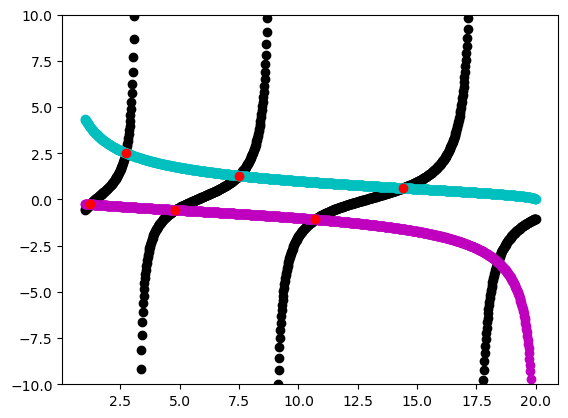

In [155]:
plt.scatter(E,Y_1(E),c="k")
plt.scatter(E,Y_2(E),c="c")
plt.scatter(E,Y_3(E),c="m")
plt.scatter(np.array(Energy_list),Y_1(np.array(Energy_list)),c='r')
plt.ylim(-10,10)
plt.show()